# Toxic Comments Classification - SVM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: Multilingual detection of hate speech against immigrants and women in Twitter (English and Spanish tweets). It is avaialble at http://hatespeech.di.unito.it/hateval.html.


The comments are divided in two classes: toxic and normal.

Algorithme used: SVC

Preprocessing techniques used:
* Convert text to lowercase
* Remove emojis and emoticons
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set4.csv')
df.head()

,id,text,tox,tokenized
0,30351,2few recognize that refugee crisis & associate...,0,"['2few', 'recognize', 'that', 'refugee', 'cris..."
1,31565,@RandomRandomero @shoe0nhead Also shut up abou...,1,"['@', 'RandomRandomero', '@', 'shoe0nhead', 'A..."
2,764,WATCH: Democratic Senator Doesn't Understand T...,1,"['WATCH', ':', 'Democratic', 'Senator', 'Does'..."
3,2106,IS-puppets tried to roll me over three times! ...,1,"['IS-puppets', 'tried', 'to', 'roll', 'me', 'o..."
4,5979,WHO.. ARE. YOOUU? This is not mario kart. You ...,1,"['WHO', '..', 'ARE', '.', 'YOOUU', '?', 'This'..."


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set4.csv')
test.head()

,id,text,tox,tokenized
0,3816,#BuildThatWall #Meritbased get the ILLEGAL sit...,1,"['#', 'BuildThatWall', '#', 'Meritbased', 'get..."
1,2737,Angels Don't Die. I think it's better that two...,0,"['Angels', 'Do', ""n't"", 'Die', '.', 'I', 'thin..."
2,5598,When your girls actin a fool so you let your s...,1,"['When', 'your', 'girls', 'actin', 'a', 'fool'..."
3,19183,@PYS_FlyATL You pussy.,0,"['@', 'PYS_FlyATL', 'You', 'pussy', '.']"
4,1699,Tomorrow night our guest speaker is Madeleine ...,0,"['Tomorrow', 'night', 'our', 'guest', 'speaker..."


# 3. Preprocessing

In [4]:
import pickle, re

# load file  
with open('../../Data/Emoji_Dict.p', 'rb') as fp:
    Emoji_Dict = pickle.load(fp)
Emoji_Dict = {v: k for k, v in Emoji_Dict.items()}

#remove empjis
def remove_emojis(text):
    for emoj in Emoji_Dict:
        text = re.sub(r'('+emoj+')', " ", text)
    return text

In [5]:
# load file
with open('../../Data/Emoticon_Dict.p', 'rb') as fl:
    Emoticon_Dict = pickle.load(fl)

# remove emoticons
def remove_emoticons(text):
    emoticon_pattern = re.compile(u'(' + u'|'.join(k for k in Emoticon_Dict) + u')')
    return emoticon_pattern.sub(r'', text)

In [6]:
stop_words = set(stopwords.words('english'))

In [7]:
print(stop_words)

{'on', 'ourselves', 'are', 'with', 'about', "needn't", 'any', 'more', 'isn', 'over', 'that', 'then', 'yourselves', 'against', "hadn't", 'each', 'me', 'will', 'their', 'aren', 'did', 'be', 'after', "should've", "you've", 'our', 'down', 'this', 'was', 'i', 'her', 'weren', 'here', 'hers', 'they', 'under', 've', 'own', 'won', 'out', 'having', 'further', 'these', 'of', 'myself', 'doesn', 'so', 'haven', 'mightn', "mightn't", 'couldn', "doesn't", "she's", "won't", 'my', 'while', 'them', 'do', 'such', 'too', 'it', 'themselves', 'when', 'at', 'same', 'wasn', 'now', 'from', 'don', 'hadn', 'where', 'below', "don't", 'am', 'herself', "didn't", 'him', 'no', "it's", 'doing', 'should', 'have', "mustn't", 'were', 's', 'to', 'there', 'both', 'theirs', 'or', 'its', 'and', 'into', 're', 'for', 'y', 'how', 'is', 'other', "you'd", 'd', "you'll", "wasn't", 'why', 't', 'needn', 'during', 'the', 'just', 'does', 'he', 'very', "isn't", 'being', 'above', 'in', 'your', 'because', 'until', 'up', 'll', 'you', 'betw

In [8]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    comment = remove_emojis(comment) # remove emojis
    comment = remove_emoticons(comment) # remove emoticons
            
    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [9]:
# clean and normalize comments
df['text'] = df['text'].map(lambda word:clean_text(word))
test['text'] = test['text'].map(lambda word:clean_text(word))

In [10]:
x_train = df['text']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(10400,)
(10400,)


In [11]:
X_test = test['text']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(2600,)
(2600,)


# 3. Classifier training (SVC)

### Create pipeline

In [12]:
# create a pipeline
SVC_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', SVC(kernel='rbf', C=1, gamma='scale'))
            ])

### Train classifier

In [13]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (SVC_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

In [14]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set4_approach#17_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [15]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.7271
recall :  0.5751
F1_score :  0.6372
precision :  0.7145


# 4. Predictions

### Test set

In [16]:
# predict test data
preds_test = cross_val_predict(SVC_pipeline, X_test, Y_test, cv=5)

In [17]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[1223  242]
 [ 517  618]]


In [18]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.70      0.83      0.76      1465
       toxic       0.72      0.54      0.62      1135

    accuracy                           0.71      2600
   macro avg       0.71      0.69      0.69      2600
weighted avg       0.71      0.71      0.70      2600



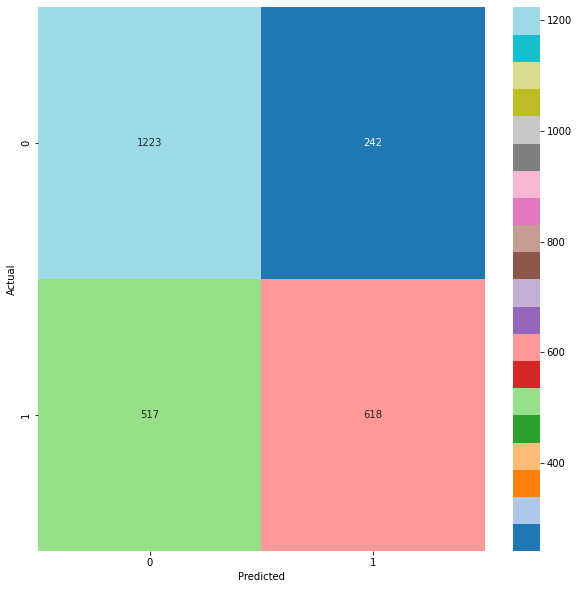

In [19]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7081
recall :  0.5445
F1_score :  0.6195
precision :  0.7186


# 5. Save results to Excel file

In [21]:
# define tarjet
newFile = "../results_set4.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #17', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 19

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)